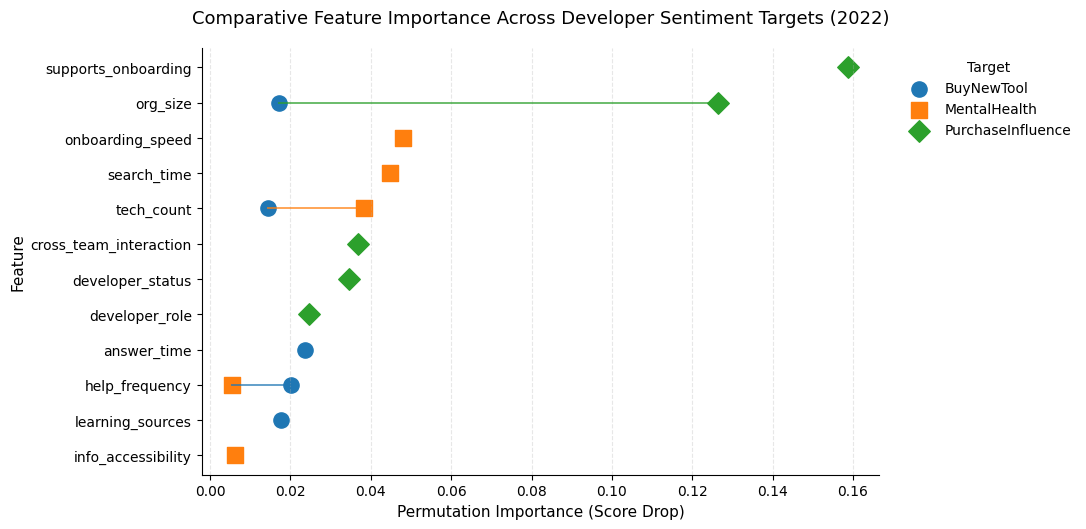

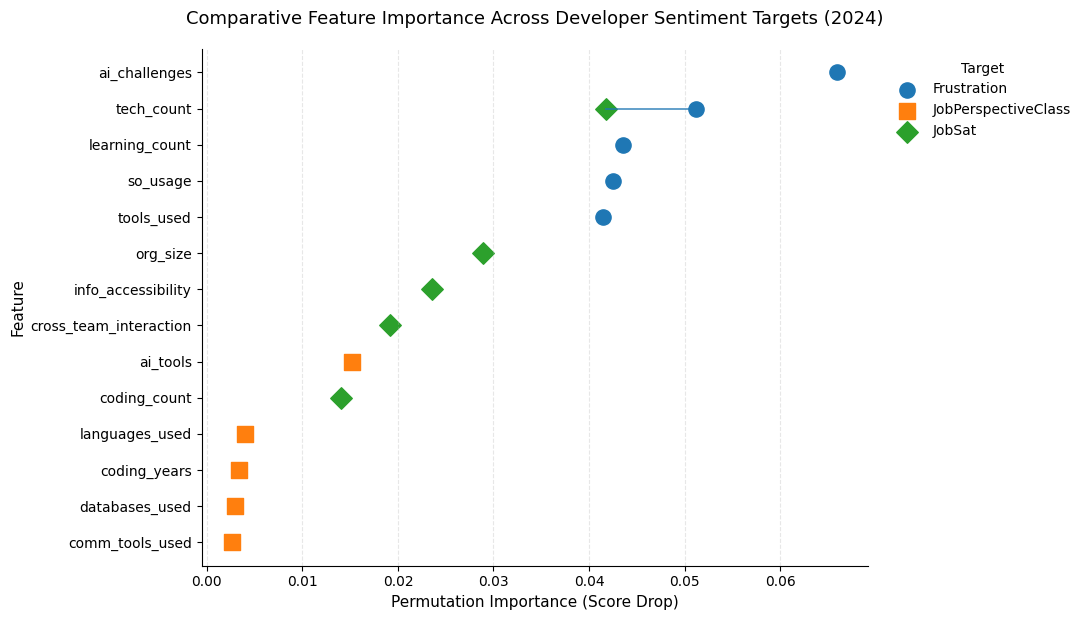

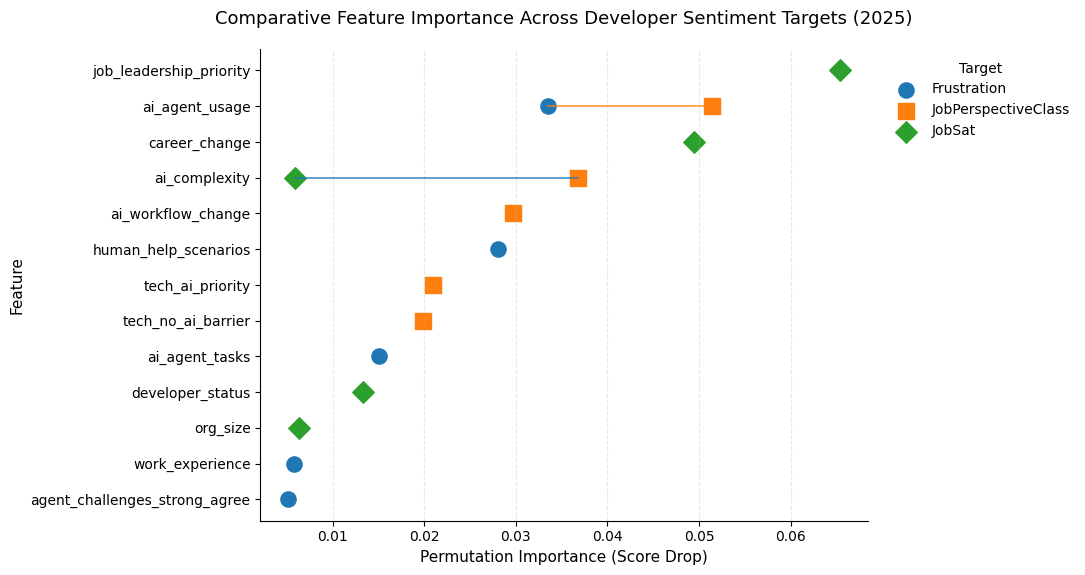

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

files = {
    "2022": "FLO_full_importance_summary_2022.csv",
    "2024": "FLO_full_importance_summary_2024.csv",
    "2025": "FLO_full_importance_summary_2025.csv"
}

markers = ["o", "s", "D", "^", "P", "X"]

for year, file in files.items():

    df = pd.read_csv(file)

    top5 = (
        df.sort_values(["target", "importance_drop"], ascending=[True, False])
          .groupby("target")
          .head(5)
    )

    pivot = top5.pivot(
        index="feature",
        columns="target",
        values="importance_drop"
    )

    pivot["max_importance"] = pivot.max(axis=1)
    pivot = pivot.sort_values("max_importance", ascending=True)
    pivot = pivot.drop(columns="max_importance")

    # 🔥 KEY FIX — dynamic but controlled height
    fig_height = max(5, len(pivot) * 0.45)

    fig, ax = plt.subplots(figsize=(11, fig_height))

    for i, target in enumerate(pivot.columns):
        ax.scatter(
            pivot[target],
            pivot.index,
            s=120,
            marker=markers[i % len(markers)],
            label=target
        )

    # connect overlapping
    for feature in pivot.index:
        values = pivot.loc[feature].dropna()
        if len(values) > 1:
            ax.plot(values.values, [feature]*len(values),
                    linewidth=1.4, alpha=0.7)

    ax.set_xlabel("Permutation Importance (Score Drop)", fontsize=11)
    ax.set_ylabel("Feature", fontsize=11)

    ax.set_title(
        f"Comparative Feature Importance Across Developer Sentiment Targets ({year})",
        fontsize=13,
        pad=18
    )

    ax.grid(axis='x', linestyle='--', alpha=0.3)

    # remove junk
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # 🔥 LEGEND OUTSIDE
    ax.legend(
        title="Target",
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        frameon=False
    )

    plt.tight_layout()

    plt.savefig(
        f"comparative_feature_importance_{year}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


Compact visualization for all years


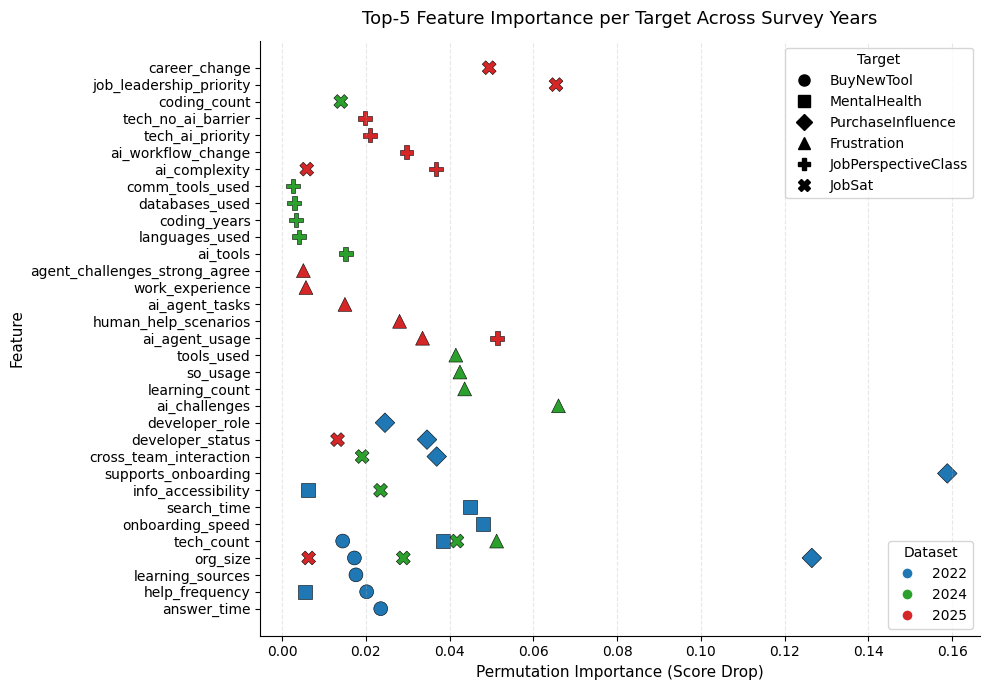

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

files = {
    "2022": "FLO_full_importance_summary_2022.csv",
    "2024": "FLO_full_importance_summary_2024.csv",
    "2025": "FLO_full_importance_summary_2025.csv"
}

dataset_colors = {
    "2022": "#1f77b4",
    "2024": "#2ca02c",
    "2025": "#d62728"
}

markers = ["o", "s", "D", "^", "P", "X"]

all_top = []

# Collect top5 per target per dataset
for year, file in files.items():

    df = pd.read_csv(file)

    top5 = (
        df.sort_values(["target", "importance_drop"], ascending=[True, False])
          .groupby("target")
          .head(5)
    )

    top5["dataset"] = year
    all_top.append(top5)

combined = pd.concat(all_top)

# Order features by max importance
feature_order = (
    combined.groupby("feature")["importance_drop"]
    .max()
    .sort_values()
    .index
)

combined["feature"] = pd.Categorical(
    combined["feature"],
    categories=feature_order,
    ordered=True
)

# 🔥 Fixed compact figure size
fig, ax = plt.subplots(figsize=(10, 7))

targets = combined["target"].unique()

for i, target in enumerate(targets):

    subset = combined[combined["target"] == target]

    ax.scatter(
        subset["importance_drop"],
        subset["feature"],
        c=subset["dataset"].map(dataset_colors),
        marker=markers[i % len(markers)],
        s=100,
        edgecolor="black",
        linewidth=0.4
    )

ax.set_xlabel("Permutation Importance (Score Drop)", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)

ax.set_title(
    "Top-5 Feature Importance per Target Across Survey Years",
    fontsize=13,
    pad=12
)

ax.grid(axis="x", linestyle="--", alpha=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# -------- Target legend (marker shapes) --------
target_handles = [
    Line2D([0], [0],
           marker=markers[i % len(markers)],
           color='black',
           linestyle='',
           label=t,
           markersize=8)
    for i, t in enumerate(targets)
]

# -------- Dataset legend (colors) --------
dataset_handles = [
    Line2D([0], [0],
           marker='o',
           color='w',
           markerfacecolor=c,
           label=year,
           markersize=8)
    for year, c in dataset_colors.items()
]

legend1 = ax.legend(handles=target_handles,
                    title="Target",
                    loc="upper right")

ax.add_artist(legend1)

ax.legend(handles=dataset_handles,
          title="Dataset",
          loc="lower right")

plt.tight_layout()

plt.savefig(
    "combined_feature_importance.png",
    dpi=300
)

plt.show()

FLO ranked features per target by number of selections


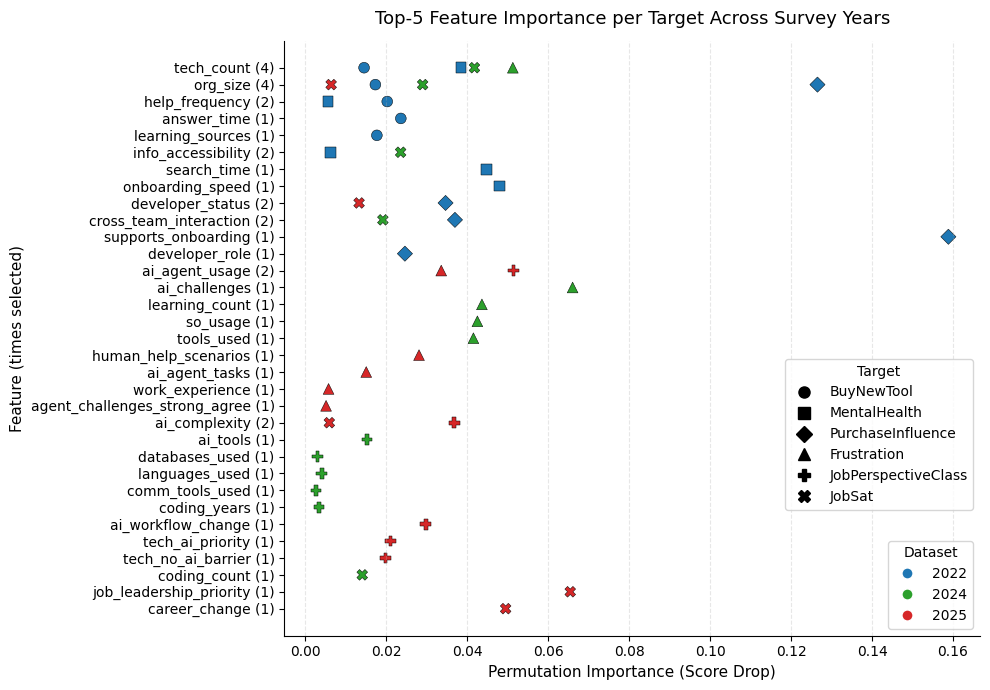

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

files = {
    "2022": "FLO_full_importance_summary_2022.csv",
    "2024": "FLO_full_importance_summary_2024.csv",
    "2025": "FLO_full_importance_summary_2025.csv"
}

dataset_colors = {
    "2022": "#1f77b4",
    "2024": "#2ca02c",
    "2025": "#d62728"
}

markers = ["o", "s", "D", "^", "P", "X"]

targets = [
    "BuyNewTool",
    "MentalHealth",
    "PurchaseInfluence",
    "Frustration",
    "JobPerspectiveClass",
    "JobSat"
]

all_top = []

# ---- Collect Top-5 features per target per dataset ----
for year, file in files.items():

    df = pd.read_csv(file)

    top5 = (
        df.sort_values(["target", "importance_drop"], ascending=[True, False])
        .groupby("target")
        .head(5)
    )

    top5["dataset"] = year
    all_top.append(top5)

combined = pd.concat(all_top)

# ---- Count how many times each feature appears ----
counts = combined["feature"].value_counts()
combined["count"] = combined["feature"].map(counts)

# ---- Create label with count ----
combined["feature_label"] = combined["feature"] + " (" + combined["count"].astype(str) + ")"

# ---- Strict ordering by count only ----
feature_order = (
    combined[["feature", "count"]]
    .drop_duplicates()
    .sort_values("count", ascending=False)
)

ordered_labels = (
    feature_order["feature"] + " (" + feature_order["count"].astype(str) + ")"
).tolist()

combined["feature_label"] = pd.Categorical(
    combined["feature_label"],
    categories=ordered_labels,
    ordered=True
)

combined = combined.sort_values("feature_label")

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 7))

for i, target in enumerate(targets):

    subset = combined[combined["target"] == target]

    ax.scatter(
        subset["importance_drop"],
        subset["feature_label"],
        c=subset["dataset"].map(dataset_colors),
        marker=markers[i],
        s=60,
        edgecolor="black",
        linewidth=0.35
    )

ax.set_xlabel("Permutation Importance (Score Drop)", fontsize=11)
ax.set_ylabel("Feature (times selected)", fontsize=11)

ax.set_title(
    "Top-5 Feature Importance per Target Across Survey Years",
    fontsize=13,
    pad=12
)

ax.grid(axis="x", linestyle="--", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ---- Target legend ----
target_handles = [
    Line2D([0], [0],
           marker=markers[i],
           color="black",
           linestyle="",
           label=t,
           markersize=8)
    for i, t in enumerate(targets)
]

# ---- Dataset legend ----
dataset_handles = [
    Line2D([0], [0],
           marker="o",
           color="w",
           markerfacecolor=c,
           label=year,
           markersize=8)
    for year, c in dataset_colors.items()
]

# ---- Target legend (symbols) ----
legend1 = ax.legend(
    handles=target_handles,
    title="Target",
    loc="lower right",
    bbox_to_anchor=(1, 0.20)
)
ax.add_artist(legend1)

# ---- Dataset legend (colors) ----
ax.legend(
    handles=dataset_handles,
    title="Dataset",
    loc="lower right"
)

# ---- Highest counts appear at top ----
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("combined_feature_importance_sorted.png", dpi=300)
plt.show()